# 02 — EDA Simple

Ce notebook constitue la deuxième étape du projet de prédiction PL & qualification LDC.

**Objectifs** :
1. Charger le dataset nettoyé depuis `data/interim/pl_cleaned.csv`
2. Analyser les distributions de base (buts, résultats, avantage domicile)
3. Explorer les tendances temporelles (évolution au fil des saisons)
4. Étudier la relation entre cotes moyennes et résultats (pour éclairer la décision sur leur traitement)
5. Analyser les statistiques de jeu (tirs, corners, cartons)
6. Identifier les premiers patterns visibles

**Règle** : pas de feature engineering ici, seulement de l'exploration descriptive pour comprendre les données.

## 2.1 — Imports et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configuration graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Détection racine projet
import os
CURRENT_DIR = Path(os.getcwd())
PROJECT_ROOT = CURRENT_DIR
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

Racine projet : /workspace
Chargement depuis : /workspace/data/interim/pl_cleaned.csv
Figures exportées vers : /workspace/reports/figures

Fichier existe ? True


In [2]:

# Chemins
CLEANED_DATA = PROJECT_ROOT / "data" / "interim" / "pl_cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Racine projet : {PROJECT_ROOT}")
print(f"Chargement depuis : {CLEANED_DATA}")
print(f"Figures exportées vers : {FIGURES_DIR}")
print(f"\nFichier existe ? {CLEANED_DATA.exists()}")

Racine projet : /workspace
Chargement depuis : /workspace/data/interim/pl_cleaned.csv
Figures exportées vers : /workspace/reports/figures

Fichier existe ? True


In [3]:
# Chargement
df = pd.read_csv(CLEANED_DATA)

# Conversion types (pour être sûr)
df['Date'] = pd.to_datetime(df['Date'])
df['Season'] = df['Season'].astype(str)
df['FTR'] = df['FTR'].astype('category')
df['HTR'] = df['HTR'].astype('category')

print(f"Dataset chargé : {df.shape}")
print(f"\nPériode : {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Saisons : {df['Season'].nunique()}")
print(f"\nAperçu :")
df.head()


Dataset chargé : (12614, 26)

Période : 1993-08-14 → 2026-05-24
Saisons : 33

Aperçu :


,Date,Season,HomeTeam,AwayTeam,Referee,FTHG,FTAG,FTR,HTHG,HTAG,...,AC,HF,AF,HY,AY,HR,AR,AvgH,AvgD,AvgA
0,1993-08-14,9394,Arsenal,Coventry,NaN,0.0,3.0,A,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1993-08-14,9394,Southampton,Everton,NaN,0.0,2.0,A,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1993-08-14,9394,Sheffield United,Swindon,NaN,3.0,1.0,H,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1993-08-14,9394,Oldham,Ipswich,NaN,0.0,3.0,A,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1993-08-14,9394,Newcastle,Tottenham,NaN,0.0,1.0,A,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# D'abord, recorriger les codes saison dans le DataFrame chargé
def fix_season_code(season):
    """Standardise les codes saison avec padding 4 chiffres"""
    if pd.isna(season):
        return None
    season_str = str(season)
    # Si c'est un nombre (ex: 1, 102), le convertir en int puis padding
    try:
        season_int = int(float(season_str))
        return str(season_int).zfill(4)
    except:
        return season_str.zfill(4)

df['Season'] = df['Season'].apply(fix_season_code)

# Maintenant, conversion en année
def season_to_year(season_code):
    """Convertit '9394' -> 1993, '0001' -> 2000, '0203' -> 2002"""
    if pd.isna(season_code):
        return None
    
    season_str = str(season_code).zfill(4)
    year_start = int(season_str[:2])
    
    if year_start >= 93:
        return 1900 + year_start
    else:
        return 2000 + year_start

df['Season_Year'] = df['Season'].apply(season_to_year)

# Vérification
print("Mapping saison -> année (CORRIGÉ) :")
season_mapping = df[['Season', 'Season_Year']].drop_duplicates().sort_values('Season_Year')
for _, row in season_mapping.iterrows():
    print(f"{row['Season']:>6} -> {row['Season_Year']}")


Mapping saison -> année (CORRIGÉ) :
  9394 -> 1993
  9495 -> 1994
  9596 -> 1995
  9697 -> 1996
  9798 -> 1997
  9899 -> 1998
  9900 -> 1999
  0001 -> 2000
  0102 -> 2001
  0203 -> 2002
  0304 -> 2003
  0405 -> 2004
  0506 -> 2005
  0607 -> 2006
  0708 -> 2007
  0809 -> 2008
  0910 -> 2009
  1011 -> 2010
  1112 -> 2011
  1213 -> 2012
  1314 -> 2013
  1415 -> 2014
  1516 -> 2015
  1617 -> 2016
  1718 -> 2017
  1819 -> 2018
  1920 -> 2019
  2021 -> 2020
  2122 -> 2021
  2223 -> 2022
  2324 -> 2023
  2425 -> 2024
  2526 -> 2025


## 2.2 — Distribution des buts et résultats

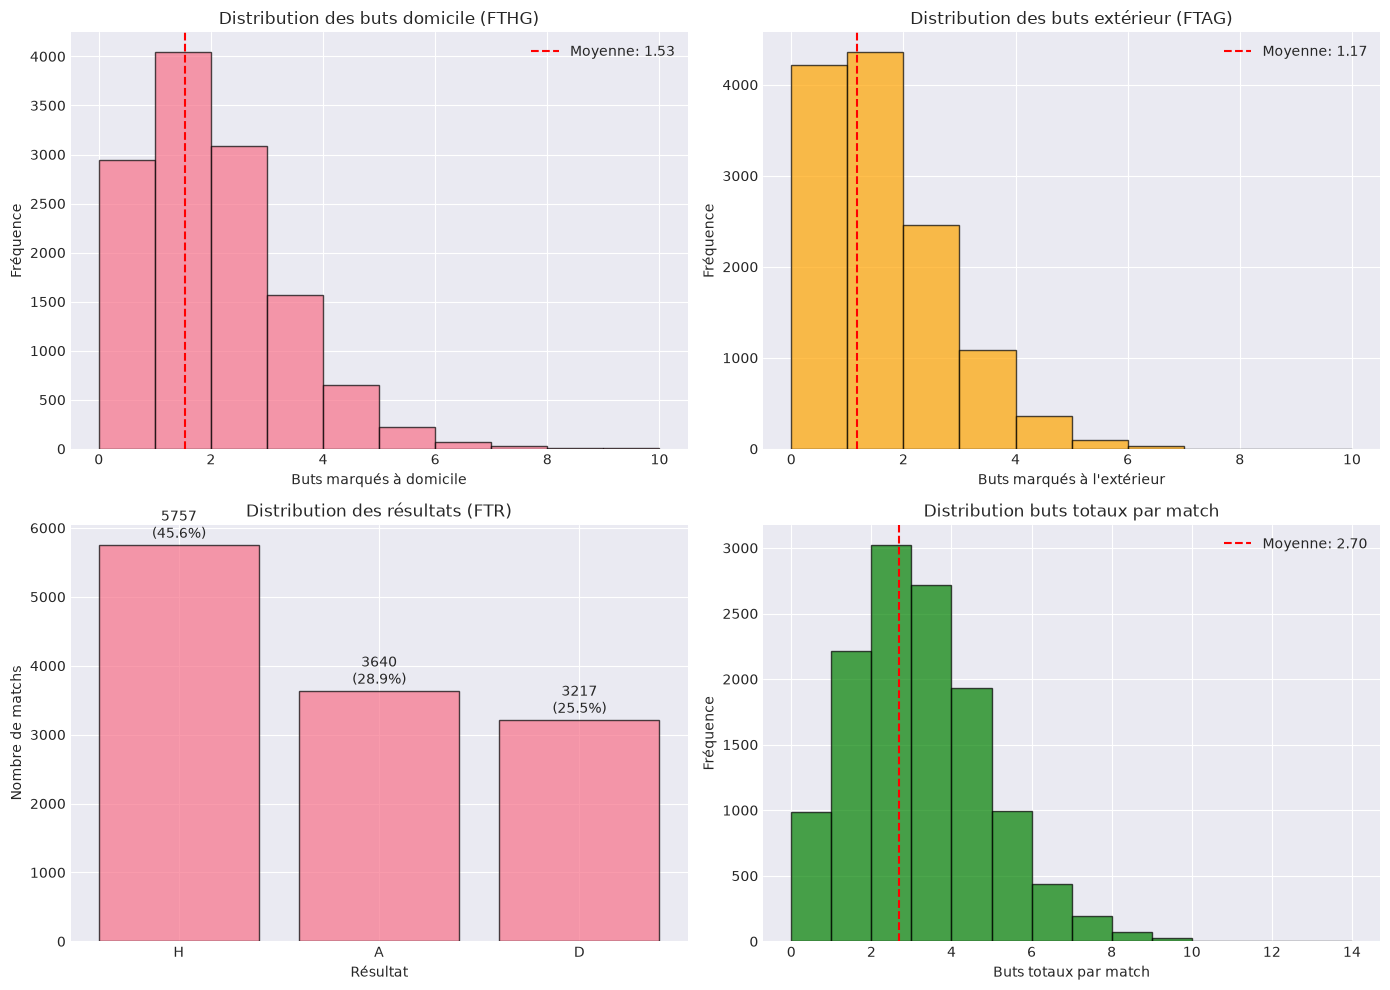

Moyenne buts domicile : 1.53
Moyenne buts extérieur : 1.17
Moyenne buts totaux : 2.70


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution buts domicile
axes[0, 0].hist(df['FTHG'].dropna(), bins=range(0, 11), edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Buts marqués à domicile')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des buts domicile (FTHG)')
axes[0, 0].axvline(df['FTHG'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["FTHG"].mean():.2f}')
axes[0, 0].legend()

# Distribution buts extérieur
axes[0, 1].hist(df['FTAG'].dropna(), bins=range(0, 11), edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Buts marqués à l\'extérieur')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution des buts extérieur (FTAG)')
axes[0, 1].axvline(df['FTAG'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["FTAG"].mean():.2f}')
axes[0, 1].legend()

# Distribution résultats
ftr_counts = df['FTR'].value_counts()
axes[1, 0].bar(ftr_counts.index, ftr_counts.values, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Résultat')
axes[1, 0].set_ylabel('Nombre de matchs')
axes[1, 0].set_title('Distribution des résultats (FTR)')
for i, v in enumerate(ftr_counts.values):
    axes[1, 0].text(i, v + 100, f'{v}\n({v/len(df)*100:.1f}%)', ha='center')

# Buts totaux par match
df['Total_Goals'] = df['FTHG'] + df['FTAG']
axes[1, 1].hist(df['Total_Goals'].dropna(), bins=range(0, 15), edgecolor='black', alpha=0.7, color='green')
axes[1, 1].set_xlabel('Buts totaux par match')
axes[1, 1].set_ylabel('Fréquence')
axes[1, 1].set_title('Distribution buts totaux par match')
axes[1, 1].axvline(df['Total_Goals'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["Total_Goals"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_distributions_buts_resultats.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Moyenne buts domicile : {df['FTHG'].mean():.2f}")
print(f"Moyenne buts extérieur : {df['FTAG'].mean():.2f}")
print(f"Moyenne buts totaux : {df['Total_Goals'].mean():.2f}")


## 2.3 — Évolution temporelle des buts

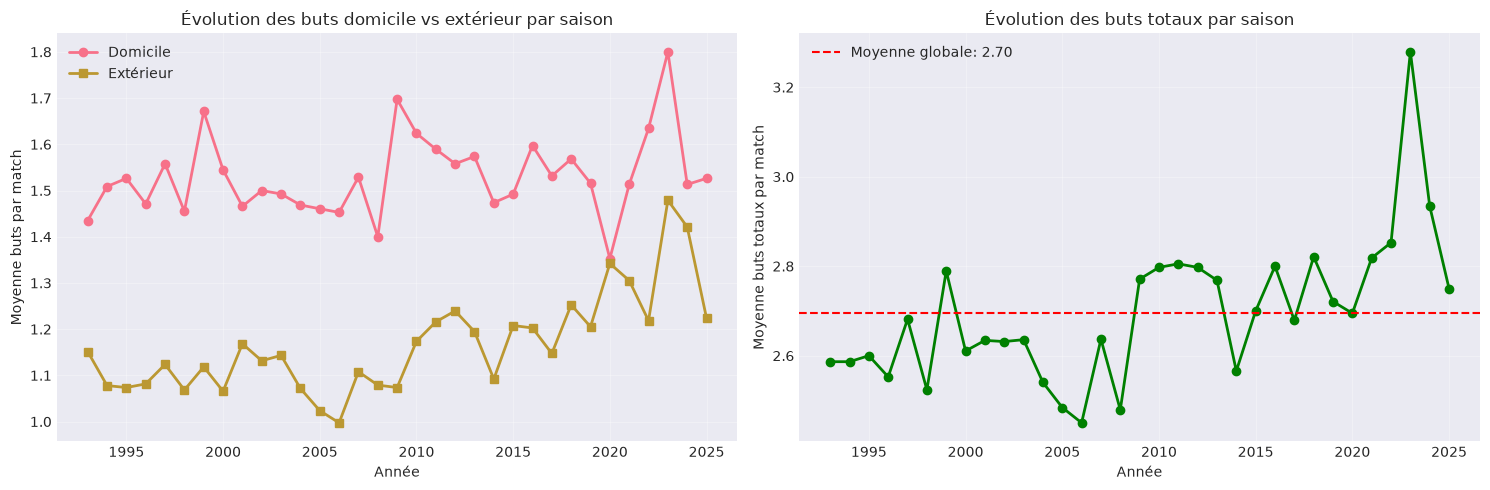

Saisons avec le plus de buts :
   Season  Season_Year  Total_Goals  Nb_Matchs
23   2324         2023     3.278947        380
24   2425         2024     2.934211        380
22   2223         2022     2.852632        380
18   1819         2018     2.821053        380
21   2122         2021     2.818421        380

Saisons avec le moins de buts :
   Season  Season_Year  Total_Goals  Nb_Matchs
6    0607         2006     2.450000        380
8    0809         2008     2.478947        380
5    0506         2005     2.484211        380
31   9899         1998     2.523684        380
4    0405         2004     2.540299        335


In [10]:
# Agrégation par saison avec tri chronologique
season_stats = df.groupby(['Season', 'Season_Year']).agg({
    'FTHG': 'mean',
    'FTAG': 'mean',
    'Total_Goals': 'mean',
    'Date': 'count'
}).rename(columns={'Date': 'Nb_Matchs'})

season_stats = season_stats.reset_index().sort_values('Season_Year')

# Graphique
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Évolution buts domicile vs extérieur
axes[0].plot(season_stats['Season_Year'], season_stats['FTHG'], marker='o', label='Domicile', linewidth=2)
axes[0].plot(season_stats['Season_Year'], season_stats['FTAG'], marker='s', label='Extérieur', linewidth=2)
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Moyenne buts par match')
axes[0].set_title('Évolution des buts domicile vs extérieur par saison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Évolution buts totaux
axes[1].plot(season_stats['Season_Year'], season_stats['Total_Goals'], marker='o', color='green', linewidth=2)
axes[1].axhline(season_stats['Total_Goals'].mean(), color='red', linestyle='--', 
                label=f'Moyenne globale: {season_stats["Total_Goals"].mean():.2f}')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Moyenne buts totaux par match')
axes[1].set_title('Évolution des buts totaux par saison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '02_evolution_buts_saison.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistiques
print("Saisons avec le plus de buts :")
print(season_stats.nlargest(5, 'Total_Goals')[['Season', 'Season_Year', 'Total_Goals', 'Nb_Matchs']])
print("\nSaisons avec le moins de buts :")
print(season_stats.nsmallest(5, 'Total_Goals')[['Season', 'Season_Year', 'Total_Goals', 'Nb_Matchs']])


## 2.4 — Avantage à domicile par saison

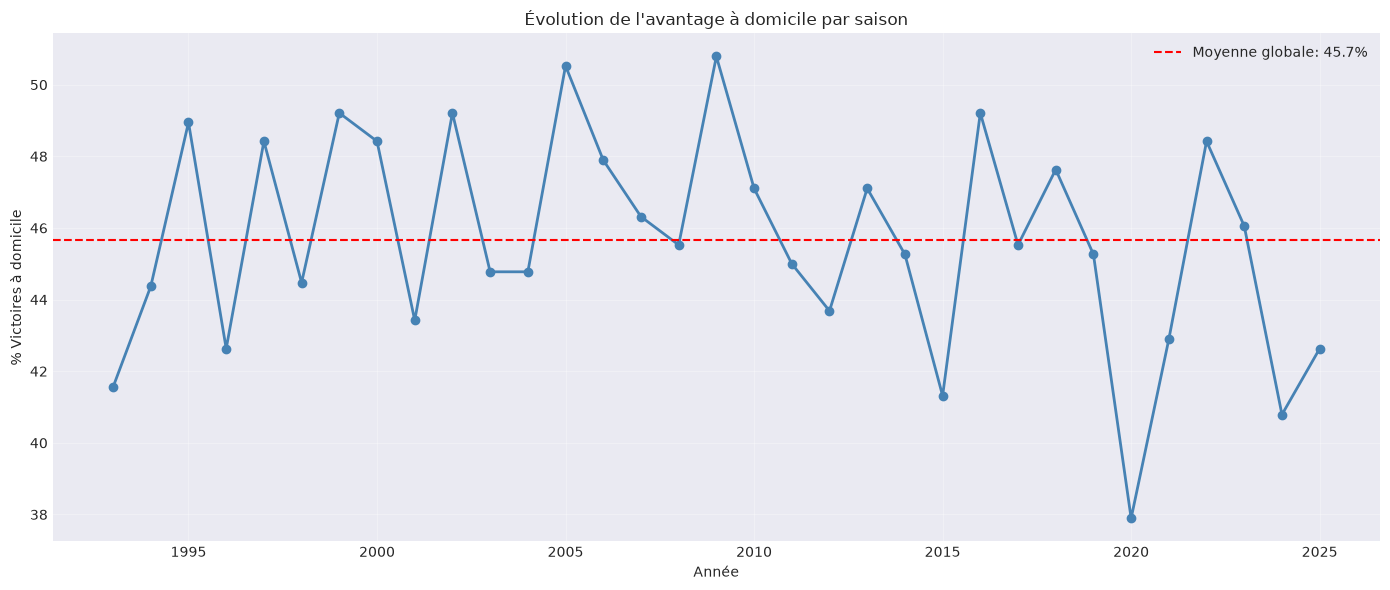

Avantage domicile moyen : 45.67%

Saison avec le PLUS d'avantage domicile :
   Season  Season_Year  Pct_Victoires_Domicile
9    0910         2009               50.789474
5    0506         2005               50.526316
32   9900         1999               49.210526

Saison avec le MOINS d'avantage domicile :
   Season  Season_Year  Pct_Victoires_Domicile
20   2021         2020               37.894737
24   2425         2024               40.789474
15   1516         2015               41.315789


In [11]:
# Calcul avantage domicile par saison
home_adv = df.groupby(['Season', 'Season_Year']).agg({
    'FTR': lambda x: (x == 'H').sum() / len(x) * 100
}).rename(columns={'FTR': 'Pct_Victoires_Domicile'})

home_adv = home_adv.reset_index().sort_values('Season_Year')

# Graphique
plt.figure(figsize=(14, 6))
plt.plot(home_adv['Season_Year'], home_adv['Pct_Victoires_Domicile'], marker='o', linewidth=2, color='steelblue')
plt.axhline(home_adv['Pct_Victoires_Domicile'].mean(), color='red', linestyle='--', 
            label=f'Moyenne globale: {home_adv["Pct_Victoires_Domicile"].mean():.1f}%')
plt.xlabel('Année')
plt.ylabel('% Victoires à domicile')
plt.title('Évolution de l\'avantage à domicile par saison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '03_avantage_domicile_saison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Avantage domicile moyen : {home_adv['Pct_Victoires_Domicile'].mean():.2f}%")
print(f"\nSaison avec le PLUS d'avantage domicile :")
print(home_adv.nlargest(3, 'Pct_Victoires_Domicile')[['Season', 'Season_Year', 'Pct_Victoires_Domicile']])
print(f"\nSaison avec le MOINS d'avantage domicile :")
print(home_adv.nsmallest(3, 'Pct_Victoires_Domicile')[['Season', 'Season_Year', 'Pct_Victoires_Domicile']])


## 2.5 — Analyse des cotes moyennes

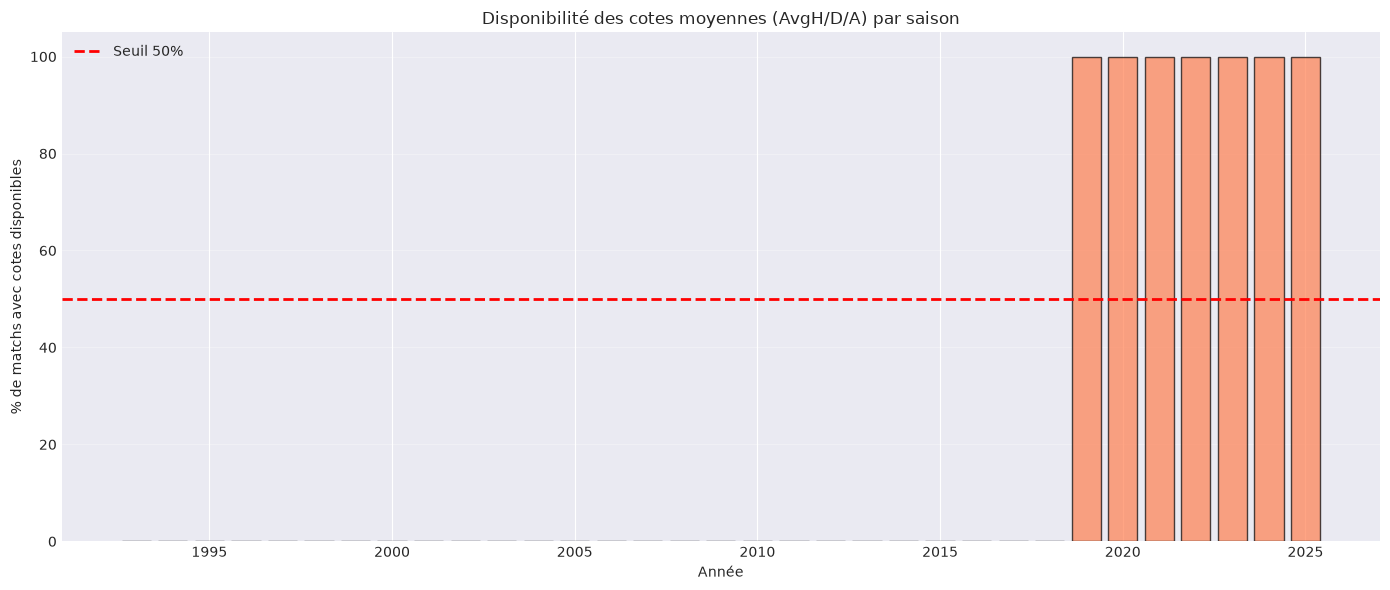

Disponibilité des cotes par saison :
   Season  Season_Year  Pct_Cotes_Disponibles  Nb_Matchs
26   9394         1993                    0.0        462
27   9495         1994                    0.0        462
28   9596         1995                    0.0        380
29   9697         1996                    0.0        380
30   9798         1997                    0.0        380
31   9899         1998                    0.0        380
32   9900         1999                    0.0        380
0    0001         2000                    0.0        380
1    0102         2001                    0.0        380
2    0203         2002                    0.0        380
3    0304         2003                    0.0        335
4    0405         2004                    0.0        335
5    0506         2005                    0.0        380
6    0607         2006                    0.0        380
7    0708         2007                    0.0        380
8    0809         2008                    0.0      

In [12]:
# Disponibilité des cotes par saison
cotes_availability = df.groupby(['Season', 'Season_Year']).agg({
    'AvgH': lambda x: x.notna().sum() / len(x) * 100,
    'Date': 'count'
}).rename(columns={'AvgH': 'Pct_Cotes_Disponibles', 'Date': 'Nb_Matchs'})

cotes_availability = cotes_availability.reset_index().sort_values('Season_Year')

# Graphique
plt.figure(figsize=(14, 6))
plt.bar(cotes_availability['Season_Year'], cotes_availability['Pct_Cotes_Disponibles'], 
        edgecolor='black', alpha=0.7, color='coral')
plt.axhline(50, color='red', linestyle='--', linewidth=2, label='Seuil 50%')
plt.xlabel('Année')
plt.ylabel('% de matchs avec cotes disponibles')
plt.title('Disponibilité des cotes moyennes (AvgH/D/A) par saison')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGURES_DIR / '04_disponibilite_cotes.png', dpi=150, bbox_inches='tight')
plt.show()

print("Disponibilité des cotes par saison :")
print(cotes_availability[['Season', 'Season_Year', 'Pct_Cotes_Disponibles', 'Nb_Matchs']])


## 2.6 — Pouvoir prédictif des cotes (sur les saisons disponibles)

In [13]:
# Filtrer les matchs avec cotes disponibles
df_with_odds = df[df['AvgH'].notna()].copy()

print(f"Matchs avec cotes : {len(df_with_odds)} / {len(df)} ({len(df_with_odds)/len(df)*100:.1f}%)")
print(f"Période couverte : {df_with_odds['Season_Year'].min()} → {df_with_odds['Season_Year'].max()}")

# Calculer le résultat prédit par les cotes (équipe avec cote la plus basse)
def predict_from_odds(row):
    """Prédit le résultat selon les cotes : cote minimale = favori"""
    if pd.isna(row['AvgH']) or pd.isna(row['AvgD']) or pd.isna(row['AvgA']):
        return None
    
    min_odd = min(row['AvgH'], row['AvgD'], row['AvgA'])
    
    if min_odd == row['AvgH']:
        return 'H'
    elif min_odd == row['AvgA']:
        return 'A'
    else:
        return 'D'

df_with_odds['Predicted_FTR'] = df_with_odds.apply(predict_from_odds, axis=1)

# Accuracy des cotes
correct_predictions = (df_with_odds['Predicted_FTR'] == df_with_odds['FTR']).sum()
accuracy = correct_predictions / len(df_with_odds) * 100

print(f"\n=== POUVOIR PRÉDICTIF DES COTES ===")
print(f"Prédictions correctes : {correct_predictions} / {len(df_with_odds)}")
print(f"Accuracy : {accuracy:.2f}%")

# Matrice de confusion
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(df_with_odds['FTR'], df_with_odds['Predicted_FTR'], labels=['H', 'D', 'A'])

print(f"\n=== MATRICE DE CONFUSION ===")
print(f"                Prédit H    Prédit D    Prédit A")
print(f"Réel H          {cm[0,0]:8d}    {cm[0,1]:8d}    {cm[0,2]:8d}")
print(f"Réel D          {cm[1,0]:8d}    {cm[1,1]:8d}    {cm[1,2]:8d}")
print(f"Réel A          {cm[2,0]:8d}    {cm[2,1]:8d}    {cm[2,2]:8d}")

print(f"\n=== RAPPORT CLASSIFICATION ===")
print(classification_report(df_with_odds['FTR'], df_with_odds['Predicted_FTR'], labels=['H', 'D', 'A']))


Matchs avec cotes : 2660 / 12614 (21.1%)
Période couverte : 2019 → 2025

=== POUVOIR PRÉDICTIF DES COTES ===
Prédictions correctes : 1449 / 2660
Accuracy : 54.47%

=== MATRICE DE CONFUSION ===
                Prédit H    Prédit D    Prédit A
Réel H               928           0         227
Réel D               378           0         251
Réel A               355           0         521

=== RAPPORT CLASSIFICATION ===
              precision    recall  f1-score   support

           H       0.56      0.80      0.66      1155
           D       0.00      0.00      0.00       629
           A       0.52      0.59      0.56       876

    accuracy                           0.54      2660
   macro avg       0.36      0.47      0.40      2660
weighted avg       0.41      0.54      0.47      2660



## 2.7 — Analyse des statistiques de jeu

In [15]:
# Focus sur les matchs avec stats de jeu disponibles
df_with_stats = df[df['HS'].notna()].copy()

print(f"=== DISPONIBILITÉ STATS DE JEU ===")
print(f"Matchs avec stats : {len(df_with_stats)} / {len(df)} ({len(df_with_stats)/len(df)*100:.1f}%)")
print(f"Période couverte : {df_with_stats['Season_Year'].min()} → {df_with_stats['Season_Year'].max()}")

# Statistiques descriptives
print(f"\n=== STATISTIQUES MOYENNES (DOMICILE vs EXTÉRIEUR) ===")

stats_summary = pd.DataFrame({
    'Stat': ['Tirs', 'Tirs cadrés', 'Corners', 'Fautes', 'Cartons jaunes', 'Cartons rouges'],
    'Domicile': [
        df_with_stats['HS'].mean(),
        df_with_stats['HST'].mean(),
        df_with_stats['HC'].mean(),
        df_with_stats['HF'].mean(),
        df_with_stats['HY'].mean(),
        df_with_stats['HR'].mean()
    ],
    'Extérieur': [
        df_with_stats['AS'].mean(),
        df_with_stats['AST'].mean(),
        df_with_stats['AC'].mean(),
        df_with_stats['AF'].mean(),
        df_with_stats['AY'].mean(),
        df_with_stats['AR'].mean()
    ]
})

stats_summary['Différence'] = stats_summary['Domicile'] - stats_summary['Extérieur']
stats_summary['Diff_%'] = (stats_summary['Différence'] / stats_summary['Extérieur'] * 100).round(1)

print(stats_summary.to_string(index=False))


=== DISPONIBILITÉ STATS DE JEU ===
Matchs avec stats : 9790 / 12614 (77.6%)
Période couverte : 2000 → 2025

=== STATISTIQUES MOYENNES (DOMICILE vs EXTÉRIEUR) ===
          Stat  Domicile  Extérieur  Différence  Diff_%
          Tirs 13.625843  10.828703    2.797140    25.8
   Tirs cadrés  5.912360   4.660981    1.251379    26.8
       Corners  6.013075   4.767314    1.245761    26.1
        Fautes 11.249438  11.730746   -0.481307    -4.1
Cartons jaunes  1.476507   1.803575   -0.327068   -18.1
Cartons rouges  0.062002   0.084270   -0.022268   -26.4


## 2.8 — Corrélation stats de jeu vs résultat

=== CORRÉLATION STATS DE JEU vs BUTS MARQUÉS ===

Corrélation avec buts domicile (FTHG) :
HST    0.439785
HS     0.291549
HC     0.037420
HF    -0.075505
HY    -0.110695
Name: FTHG, dtype: float64

Corrélation avec buts extérieur (FTAG) :
AST    0.458343
AS     0.322965
AC     0.046799
AY    -0.033082
AF    -0.048610
Name: FTAG, dtype: float64


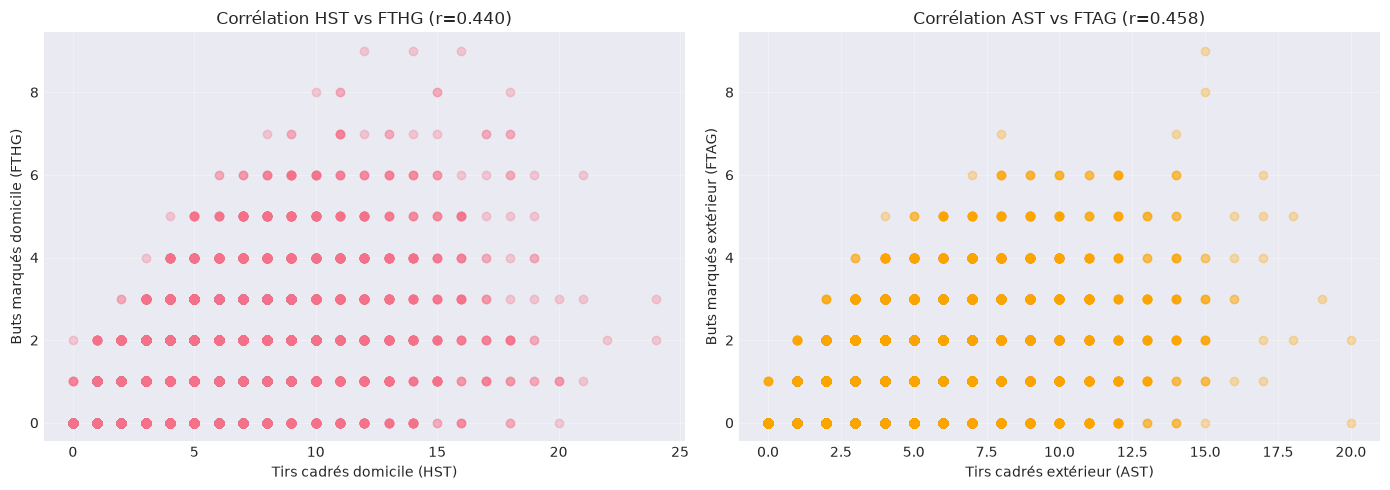

In [16]:
# Corrélation entre stats et buts marqués
print("=== CORRÉLATION STATS DE JEU vs BUTS MARQUÉS ===\n")

# Domicile
home_corr = df_with_stats[['FTHG', 'HS', 'HST', 'HC', 'HF', 'HY']].corr()['FTHG'].drop('FTHG').sort_values(ascending=False)
print("Corrélation avec buts domicile (FTHG) :")
print(home_corr)

# Extérieur
away_corr = df_with_stats[['FTAG', 'AS', 'AST', 'AC', 'AF', 'AY']].corr()['FTAG'].drop('FTAG').sort_values(ascending=False)
print("\nCorrélation avec buts extérieur (FTAG) :")
print(away_corr)

# Graphique corrélation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domicile
axes[0].scatter(df_with_stats['HST'], df_with_stats['FTHG'], alpha=0.3)
axes[0].set_xlabel('Tirs cadrés domicile (HST)')
axes[0].set_ylabel('Buts marqués domicile (FTHG)')
axes[0].set_title(f'Corrélation HST vs FTHG (r={df_with_stats[["HST", "FTHG"]].corr().iloc[0,1]:.3f})')
axes[0].grid(True, alpha=0.3)

# Extérieur
axes[1].scatter(df_with_stats['AST'], df_with_stats['FTAG'], alpha=0.3, color='orange')
axes[1].set_xlabel('Tirs cadrés extérieur (AST)')
axes[1].set_ylabel('Buts marqués extérieur (FTAG)')
axes[1].set_title(f'Corrélation AST vs FTAG (r={df_with_stats[["AST", "FTAG"]].corr().iloc[0,1]:.3f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_DIR / '05_correlation_tirs_buts.png', dpi=150, bbox_inches='tight')
plt.show()


## 2.9 — Analyse des scores mi-temps

In [17]:
# Focus matchs avec données mi-temps
df_with_ht = df[df['HTHG'].notna()].copy()

print(f"=== SCORES MI-TEMPS ===")
print(f"Matchs avec données mi-temps : {len(df_with_ht)} / {len(df)} ({len(df_with_ht)/len(df)*100:.1f}%)")
print(f"Période : {df_with_ht['Season_Year'].min()} → {df_with_ht['Season_Year'].max()}")

# Stats descriptives mi-temps
print(f"\n=== STATISTIQUES MI-TEMPS ===")
print(f"Moyenne buts mi-temps domicile : {df_with_ht['HTHG'].mean():.2f}")
print(f"Moyenne buts mi-temps extérieur : {df_with_ht['HTAG'].mean():.2f}")
print(f"Moyenne buts totaux mi-temps : {(df_with_ht['HTHG'] + df_with_ht['HTAG']).mean():.2f}")

# Buts marqués en 2ème mi-temps
df_with_ht['Goals_2H_Home'] = df_with_ht['FTHG'] - df_with_ht['HTHG']
df_with_ht['Goals_2H_Away'] = df_with_ht['FTAG'] - df_with_ht['HTAG']
df_with_ht['Goals_2H_Total'] = df_with_ht['Goals_2H_Home'] + df_with_ht['Goals_2H_Away']

print(f"\n=== STATISTIQUES 2ÈME MI-TEMPS ===")
print(f"Moyenne buts 2MT domicile : {df_with_ht['Goals_2H_Home'].mean():.2f}")
print(f"Moyenne buts 2MT extérieur : {df_with_ht['Goals_2H_Away'].mean():.2f}")
print(f"Moyenne buts totaux 2MT : {df_with_ht['Goals_2H_Total'].mean():.2f}")

# Répartition 1MT vs 2MT
pct_1h = ((df_with_ht['HTHG'] + df_with_ht['HTAG']).sum() / df_with_ht['Total_Goals'].sum() * 100)
pct_2h = 100 - pct_1h
print(f"\nRépartition des buts : {pct_1h:.1f}% en 1MT, {pct_2h:.1f}% en 2MT")


=== SCORES MI-TEMPS ===
Matchs avec données mi-temps : 11690 / 12614 (92.7%)
Période : 1995 → 2025

=== STATISTIQUES MI-TEMPS ===
Moyenne buts mi-temps domicile : 0.69
Moyenne buts mi-temps extérieur : 0.51
Moyenne buts totaux mi-temps : 1.20

=== STATISTIQUES 2ÈME MI-TEMPS ===
Moyenne buts 2MT domicile : 0.84
Moyenne buts 2MT extérieur : 0.66
Moyenne buts totaux 2MT : 1.50

Répartition des buts : 44.4% en 1MT, 55.6% en 2MT


## 2.10 — Pouvoir prédictif du score mi-temps

In [18]:
# Analyse : si on mène à la mi-temps, quelle probabilité de gagner ?
print("=== POUVOIR PRÉDICTIF DU SCORE MI-TEMPS ===\n")

# Matrice : résultat mi-temps → résultat final
ht_ft_matrix = pd.crosstab(df_with_ht['HTR'], df_with_ht['FTR'], normalize='index') * 100

print("Probabilité de résultat final selon résultat mi-temps (%) :")
print(ht_ft_matrix.round(1))

# Statistiques clés
home_winning_ht = df_with_ht[df_with_ht['HTR'] == 'H']
home_win_rate = (home_winning_ht['FTR'] == 'H').sum() / len(home_winning_ht) * 100

draw_ht = df_with_ht[df_with_ht['HTR'] == 'D']
draw_outcomes = draw_ht['FTR'].value_counts(normalize=True) * 100

away_winning_ht = df_with_ht[df_with_ht['HTR'] == 'A']
away_win_rate = (away_winning_ht['FTR'] == 'A').sum() / len(away_winning_ht) * 100

print(f"\n=== STATISTIQUES CLÉS ===")
print(f"Si domicile mène à la MT → victoire finale : {home_win_rate:.1f}%")
print(f"Si match nul à la MT → distribution finale :")
for outcome, pct in draw_outcomes.items():
    print(f"  {outcome}: {pct:.1f}%")
print(f"Si extérieur mène à la MT → victoire finale : {away_win_rate:.1f}%")


=== POUVOIR PRÉDICTIF DU SCORE MI-TEMPS ===

Probabilité de résultat final selon résultat mi-temps (%) :
FTR     A     D     H
HTR                  
A    70.0  19.8  10.1
D    25.6  37.4  37.0
H     5.4  14.4  80.1

=== STATISTIQUES CLÉS ===
Si domicile mène à la MT → victoire finale : 80.1%
Si match nul à la MT → distribution finale :
  D: 37.4%
  H: 37.0%
  A: 25.6%
Si extérieur mène à la MT → victoire finale : 70.0%


## 2.11 — Analyse par équipe (top performers)

In [19]:
# Agrégation par équipe (toutes saisons confondues)
all_teams = pd.concat([
    df[['HomeTeam']].rename(columns={'HomeTeam': 'Team'}),
    df[['AwayTeam']].rename(columns={'AwayTeam': 'Team'})
])

teams_count = all_teams['Team'].value_counts()

print(f"=== ÉQUIPES ===")
print(f"Nombre d'équipes uniques : {teams_count.nunique()}")
print(f"\nTop 10 équipes (par nombre de matchs) :")
print(teams_count.head(10))

# Calcul performances par équipe (domicile + extérieur)
team_stats = []

for team in teams_count.head(20).index:  # Top 20 équipes
    home_matches = df[df['HomeTeam'] == team]
    away_matches = df[df['AwayTeam'] == team]
    
    total_matches = len(home_matches) + len(away_matches)
    
    # Victoires
    home_wins = (home_matches['FTR'] == 'H').sum()
    away_wins = (away_matches['FTR'] == 'A').sum()
    total_wins = home_wins + away_wins
    
    # Nuls
    home_draws = (home_matches['FTR'] == 'D').sum()
    away_draws = (away_matches['FTR'] == 'D').sum()
    total_draws = home_draws + away_draws
    
    # Buts
    goals_scored = home_matches['FTHG'].sum() + away_matches['FTAG'].sum()
    goals_conceded = home_matches['FTAG'].sum() + away_matches['FTHG'].sum()
    
    win_rate = total_wins / total_matches * 100
    
    team_stats.append({
        'Team': team,
        'Matchs': total_matches,
        'Victoires': total_wins,
        'Nuls': total_draws,
        'Win_%': win_rate,
        'Buts_pour': goals_scored,
        'Buts_contre': goals_conceded,
        'Diff': goals_scored - goals_conceded
    })

team_stats_df = pd.DataFrame(team_stats).sort_values('Win_%', ascending=False)

print(f"\n=== TOP 10 ÉQUIPES (par % victoires) ===")
print(team_stats_df.head(10).to_string(index=False))


=== ÉQUIPES ===
Nombre d'équipes uniques : 35

Top 10 équipes (par nombre de matchs) :
Team
Liverpool      1253
Tottenham      1253
Everton        1253
Man United     1253
Arsenal        1252
Chelsea        1252
Newcastle      1176
West Ham       1148
Aston Villa    1140
Man City       1063
Name: count, dtype: int64

=== TOP 10 ÉQUIPES (par % victoires) ===
       Team  Matchs  Victoires  Nuls     Win_%  Buts_pour  Buts_contre   Diff
 Man United    1253        745   276 59.457302     2331.0       1232.0 1099.0
    Arsenal    1252        696   304 55.591054     2270.0       1237.0 1033.0
  Liverpool    1253        676   306 53.950519     2258.0       1262.0  996.0
    Chelsea    1252        661   306 52.795527     2145.0       1270.0  875.0
   Man City    1063        555   222 52.210724     1925.0       1152.0  773.0
  Tottenham    1253        543   296 43.335994     1932.0       1608.0  324.0
  Newcastle    1176        452   290 38.435374     1641.0       1603.0   38.0
      Leeds     

## 2.12 — Visualisation finale : heatmap corrélations

Corrélations calculées sur 9790 matchs


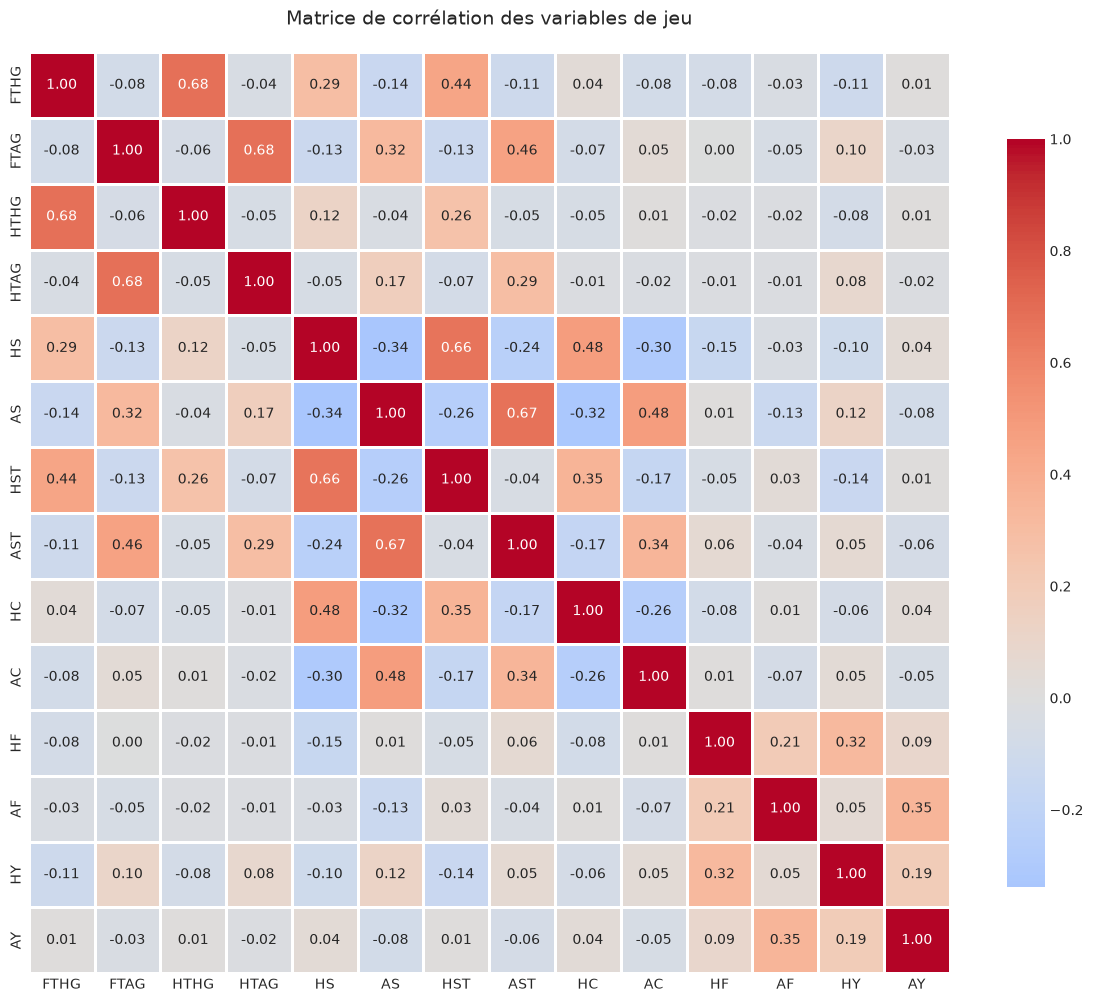


Corrélations les plus fortes avec buts marqués :

Domicile (FTHG) :
HTHG    0.684022
HST     0.439785
HS      0.291549
HC      0.037420
AY      0.012299
Name: FTHG, dtype: float64

Extérieur (FTAG) :
HTAG    0.683929
AST     0.458343
AS      0.322965
HY      0.104355
AC      0.046799
Name: FTAG, dtype: float64


In [20]:
# Sélection variables numériques pertinentes pour corrélation
corr_vars = ['FTHG', 'FTAG', 'HTHG', 'HTAG', 'HS', 'AS', 'HST', 'AST', 
             'HC', 'AC', 'HF', 'AF', 'HY', 'AY']

# Sous-ensemble avec toutes ces variables disponibles
df_corr = df[corr_vars].dropna()

print(f"Corrélations calculées sur {len(df_corr)} matchs")

# Matrice de corrélation
corr_matrix = df_corr.corr()

# Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de corrélation des variables de jeu', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrélations les plus fortes avec buts marqués :")
print("\nDomicile (FTHG) :")
print(corr_matrix['FTHG'].drop('FTHG').sort_values(ascending=False).head(5))
print("\nExtérieur (FTAG) :")
print(corr_matrix['FTAG'].drop('FTAG').sort_values(ascending=False).head(5))


---

## Synthèse de l'EDA Simple

### Distributions et tendances générales

✅ **Avantage domicile confirmé** :
- 45.7% victoires domicile vs 28.9% extérieur
- 1.53 buts/match domicile vs 1.17 extérieur (+31%)
- Effet décroissant dans le temps (max 50.8% en 2009, min 37.9% en 2020 - COVID)

✅ **Évolution temporelle** :
- Football plus offensif depuis 2018 (3.28 buts/match en 2023/24)
- Période défensive 2005-2008 (minimum 2.45 buts/match)
- 2ème mi-temps plus offensive : 55.6% des buts

✅ **Score mi-temps = meilleur prédicteur** :
- Si domicile mène MT → 80.1% victoire finale
- Si extérieur mène MT → 70.0% victoire finale
- Corrélation 0.68 avec score final

### Variables prédictives

**Hiérarchie établie** :
1. **Score mi-temps (r=0.68)** : variable la plus prédictive
2. **Tirs cadrés (r=0.44-0.46)** : meilleure stat de jeu
3. **Tirs totaux (r=0.29-0.32)** : utile mais moins que cadrés
4. **Corners, fautes, cartons** : corrélations faibles (<0.1)

**Cotes moyennes** :
- Disponibles seulement 2019-2025 (21% des données)
- Accuracy 54.5% mais ne prédisent jamais de nuls
- **Décision** : garder toutes les saisons, cotes deviennent optionnelles

### Disponibilité des données

| Variable | Disponibilité | Période |
|---|---|---|
| Buts, résultats | 100% | 1993-2025 |
| Scores mi-temps | 92.7% | 1995-2025 |
| Stats de jeu | 77.6% | 2000-2025 |
| Cotes moyennes | 21.1% | 2019-2025 |

### Top équipes historiques

**Big 6** (par % victoires) :
1. Man United (59.5%)
2. Arsenal (55.6%)
3. Liverpool (54.0%)
4. Chelsea (52.8%)
5. Man City (52.2%)
6. Tottenham (43.3%)

**Prochaine étape** : Notebook 03 (EDA approfondie) analysera les croisements thématiques : forme vs résultat, xG (quand disponible), valeur marchande, patterns avancés.

**Prochaine étape ensuite** : Notebook 04 (Tests statistiques) validera ces observations avec des tests formels (Mann-Whitney, Kruskal-Wallis, chi², corrections multiples).
